# ScienceQA Data Analysis

**Goal:** Characterize the dataset before training. Answer three questions:
1. What does the data look like? (distributions, lengths, image properties)
2. Where is the headroom? (zero-shot baselines under different conditions)
3. What needs preprocessing?

This notebook is read-only on the data — no training, no submission writing.

## 0. Setup

In [ ]:
# Run once if needed
# !pip install -q transformers==4.57.6 pandas numpy matplotlib pillow tqdm

In [3]:
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("")

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 100

## 1. Load Data

Parse the JSON `choices` column. Print column parity and missingness across splits.

In [4]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

for df in (train_df, val_df, test_df):
    df["choices"] = df["choices"].apply(json.loads)

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Columns: {list(train_df.columns)}")
train_df.head(3)

Train: 3,109  |  Val: 1,048  |  Test: 1,008
Columns: ['id', 'image_path', 'question', 'choices', 'num_choices', 'answer', 'hint', 'lecture', 'solution', 'task', 'grade', 'subject', 'topic', 'category', 'skill']


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool of water increase the reproductive success of a male Amazonian poison...,"[the male's tadpoles will be larger when they hatch, the male will carry his tadpoles through the forest, the male's...",3,2,Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific...,Animals increase their reproductive success when they have offspring that survive to reproduce.\nAnimals can increas...,Look for the part of the passage that describes the effect of putting each tadpole in its own pool of water. Use thi...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with other females increase the reproductive success of a female baboon? Compl...,"[the female's offspring will live longer, the female will spend more time grooming other baboons, the female's offsp...",3,0,Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific...,Animals increase their reproductive success when they have offspring that survive to reproduce.\nAnimals can increas...,Look for the part of the passage that describes the effect of forming strong social bonds with other females. Use th...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim
2,train_00927,images/train/train_00927.png,Why might raising cubs with other lionesses in a pride increase an African lioness's reproductive success? Complete ...,"[the lioness's cubs will be around other cubs, the lioness's cubs will survive attacks, the lioness will feed the cu...",3,1,Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific...,Animals increase their reproductive success when they have offspring that survive to reproduce.\nAnimals can increas...,Look for the part of the passage that describes the effect of raising cubs with other lionesses in a pride. Use this...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive success? Identify evidence to support a claim


In [5]:
# Confirm test has no answer leak, and check column parity
print("Train columns:", set(train_df.columns))
print("Test columns: ", set(test_df.columns))
print("In train but not test:", set(train_df.columns) - set(test_df.columns))

Train columns: {'hint', 'image_path', 'grade', 'question', 'answer', 'choices', 'lecture', 'num_choices', 'solution', 'topic', 'category', 'subject', 'skill', 'task', 'id'}
Test columns:  {'hint', 'image_path', 'grade', 'question', 'lecture', 'choices', 'num_choices', 'topic', 'category', 'skill', 'subject', 'task', 'id'}
In train but not test: {'solution', 'answer'}


In [6]:
missing = pd.DataFrame({
    "train_missing_pct": train_df.isna().mean() * 100,
    "val_missing_pct":   val_df.isna().mean() * 100,
    "test_missing_pct":  test_df.isna().mean() * 100,
}).round(1)
missing

,train_missing_pct,val_missing_pct,test_missing_pct
answer,0.0,0.0,NaN
category,0.0,0.0,0.0
choices,0.0,0.0,0.0
grade,0.0,0.0,0.0
hint,23.3,22.1,21.2
id,0.0,0.0,0.0
image_path,0.0,0.0,0.0
lecture,14.2,12.7,18.2
num_choices,0.0,0.0,0.0
question,0.0,0.0,0.0


## 2. Distribution Analysis

Three things matter for downstream decisions:
- `num_choices` per question (drives inference-scoring code)
- Position of the correct answer (position bias)
- Subject / grade / category balance

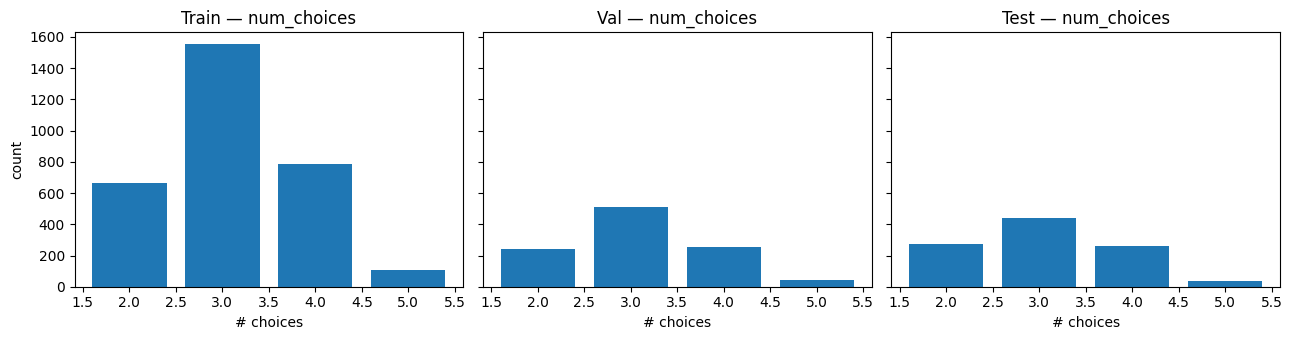

Train num_choices distribution:
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, df, name in zip(axes, [train_df, val_df, test_df], ["Train", "Val", "Test"]):
    counts = df["num_choices"].value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{name} — num_choices")
    ax.set_xlabel("# choices")
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()

print("Train num_choices distribution:")
print(train_df["num_choices"].value_counts().sort_index())

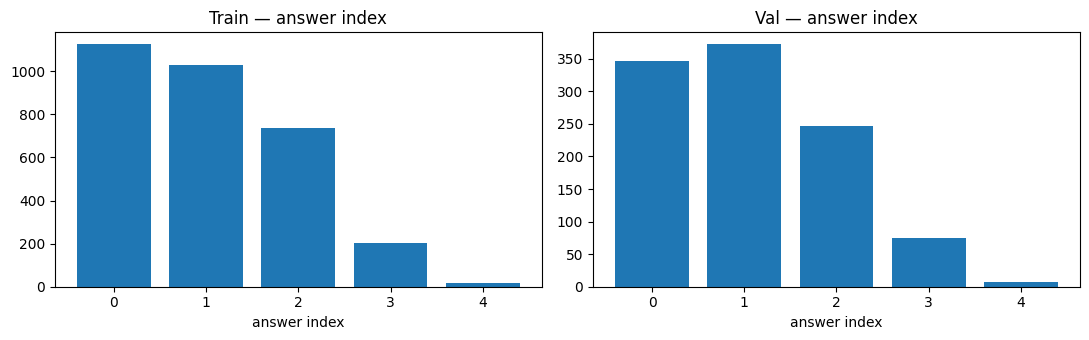


Train answer distribution by num_choices:
  2 choices (  664 ex): [0.506, 0.494]
  3 choices ( 1552 ex): [0.348, 0.312, 0.34]
  4 choices (  783 ex): [0.28, 0.241, 0.25, 0.229]
  5 choices (  110 ex): [0.264, 0.236, 0.127, 0.227, 0.145]


In [8]:
# Answer index distribution (only meaningful where answers exist)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, df, name in zip(axes, [train_df, val_df], ["Train", "Val"]):
    counts = df["answer"].value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{name} — answer index")
    ax.set_xlabel("answer index")
plt.tight_layout(); plt.show()

# Answer-index distribution conditional on num_choices
print("\nTrain answer distribution by num_choices:")
for n in sorted(train_df["num_choices"].unique()):
    sub = train_df[train_df["num_choices"] == n]
    dist = sub["answer"].value_counts(normalize=True).sort_index().round(3).tolist()
    print(f"  {n} choices ({len(sub):>5} ex): {dist}")

In [9]:
# Subject / grade / topic breakdown
for col in ["subject", "grade", "category", "task"]:
    print(f"\n=== {col} ===")
    print(train_df[col].value_counts().head(10))


=== subject ===
subject
natural science     2264
social science       768
language science      77
Name: count, dtype: int64

=== grade ===
grade
grade8     685
grade6     611
grade7     545
grade4     484
grade5     354
grade3     289
grade2     115
grade12     21
grade1       5
Name: count, dtype: int64

=== category ===
category
Designing experiments                 222
Solutions                             222
Ecosystems                            195
Maps                                  190
Velocity, acceleration, and forces    186
Magnets                               179
Engineering practices                 174
Particle motion and energy            169
Basic economic principles             163
Geography                             160
Name: count, dtype: int64

=== task ===
task
closed choice    3071
true-or false      38
Name: count, dtype: int64


In [10]:
# Cross-split parity: does test look like train in terms of subject mix?
subjects = pd.DataFrame({
    "train": train_df["subject"].value_counts(normalize=True),
    "val":   val_df["subject"].value_counts(normalize=True),
    "test":  test_df["subject"].value_counts(normalize=True),
}).fillna(0).round(3)
subjects

,train,val,test
subject,,,
natural science,0.728,0.741,0.732
social science,0.247,0.232,0.241
language science,0.025,0.027,0.027


## 3. Text Length Analysis

Prompt length drives the `max_length` choice for training and how aggressively to truncate.

In [11]:
def text_len(s):
    return 0 if not isinstance(s, str) else len(s.split())

for col in ["question", "hint", "lecture"]:
    train_df[f"{col}_words"] = train_df[col].apply(text_len)

train_df["choices_total_words"] = train_df["choices"].apply(
    lambda cs: sum(len(str(c).split()) for c in cs)
)
train_df["prompt_words"] = (
    train_df["question_words"]
    + train_df["hint_words"]
    + train_df["lecture_words"]
    + train_df["choices_total_words"]
)

print(train_df[["question_words", "hint_words", "lecture_words",
                "choices_total_words", "prompt_words"]].describe(
                    percentiles=[0.5, 0.9, 0.95, 0.99]
                ).round(1))

       question_words  hint_words  lecture_words  choices_total_words  \
count          3109.0      3109.0         3109.0               3109.0   
mean             11.9        40.9          115.9                 15.6   
std               5.4        45.8           82.8                 12.4   
min               3.0         0.0            0.0                  2.0   
50%              11.0        28.0           97.0                 10.0   
90%              18.0       114.0          245.0                 34.0   
95%              20.0       146.0          254.0                 35.0   
99%              39.0       165.9          343.0                 45.0   
max              50.0       304.0          365.0                 51.0   

       prompt_words  
count        3109.0  
mean          184.3  
std           110.3  
min            13.0  
50%           153.0  
90%           391.0  
95%           409.0  
99%           439.0  
max           506.0  


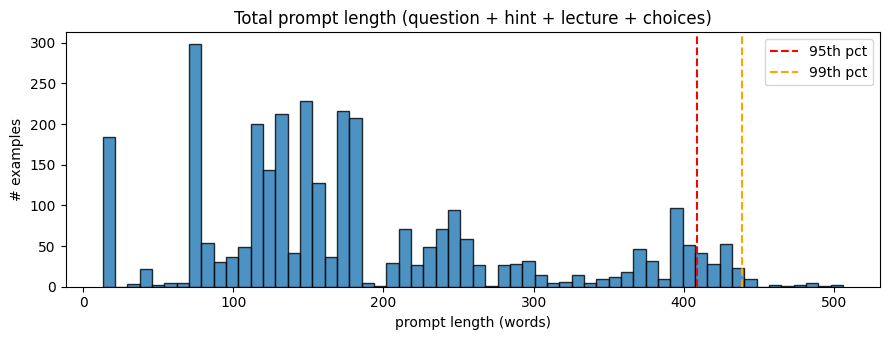

In [12]:
# Visualize prompt length distribution
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(train_df["prompt_words"], bins=60, edgecolor="black", alpha=0.8)
ax.axvline(train_df["prompt_words"].quantile(0.95), color="red",
           linestyle="--", label="95th pct")
ax.axvline(train_df["prompt_words"].quantile(0.99), color="orange",
           linestyle="--", label="99th pct")
ax.set_xlabel("prompt length (words)")
ax.set_ylabel("# examples")
ax.set_title("Total prompt length (question + hint + lecture + choices)")
ax.legend()
plt.tight_layout(); plt.show()

In [13]:
# Token-level lengths using SmolVLM's actual tokenizer
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

CHOICE_LETTERS = "ABCDEFGHIJ"
def build_prompt_text(row):
    parts = []
    if isinstance(row.get("lecture"), str) and row["lecture"].strip():
        parts.append(row["lecture"].strip())
    if isinstance(row.get("hint"), str) and row["hint"].strip():
        parts.append(row["hint"].strip())
    ctx = "\n".join(parts)
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(row["choices"])
    )
    s = "<image>\n"
    if ctx:
        s += f"Context:\n{ctx}\n\n"
    s += f"Question: {row['question']}\nChoices:\n{choices_str}\nAnswer:"
    return s

# Sample 1000 rows for speed
sample = train_df.sample(min(1000, len(train_df)), random_state=SEED)
tok_lens = [len(tok.encode(build_prompt_text(r))) for _, r in tqdm(sample.iterrows(),
                                                                    total=len(sample))]
tok_lens = np.array(tok_lens)
print(f"Token-length percentiles (sample n={len(sample)}):")
for q in [50, 75, 90, 95, 99, 100]:
    print(f"  p{q:>3}: {int(np.percentile(tok_lens, q))} tokens")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

100%|██████████| 1000/1000 [00:00<00:00, 3968.59it/s]

Token-length percentiles (sample n=1000):
  p 50: 205 tokens
  p 75: 310 tokens
  p 90: 488 tokens
  p 95: 508 tokens
  p 99: 567 tokens
  p100: 684 tokens


## 4. Image Analysis

How big are the images and what kinds of visual content are present?

100%|██████████| 500/500 [00:00<00:00, 10903.25it/s]


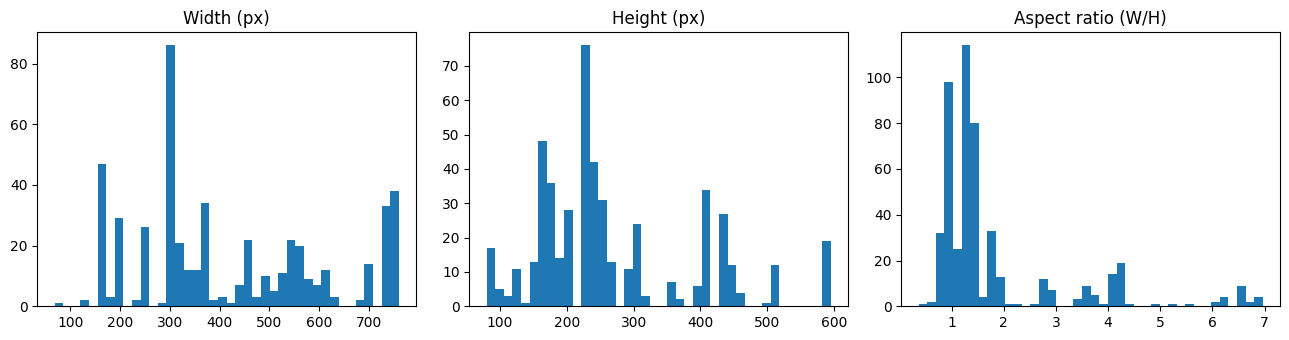

Width  — median 378, p95 750
Height — median 232, p95 506
Aspect — median 1.32, range 0.37–6.97


In [15]:
# Image size distribution — sample for speed
img_sample = train_df.sample(min(500, len(train_df)), random_state=SEED)
sizes = []
for _, row in tqdm(img_sample.iterrows(), total=len(img_sample)):
    p = DATA_DIR / row["image_path"]
    try:
        with Image.open(p) as im:
            sizes.append(im.size)  # (width, height)
    except Exception as e:
        print(f"Failed: {p} ({e})")

widths  = np.array([s[0] for s in sizes])
heights = np.array([s[1] for s in sizes])
aspect  = widths / heights

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(widths,  bins=40); axes[0].set_title("Width (px)")
axes[1].hist(heights, bins=40); axes[1].set_title("Height (px)")
axes[2].hist(aspect,  bins=40); axes[2].set_title("Aspect ratio (W/H)")
plt.tight_layout(); plt.show()

print(f"Width  — median {int(np.median(widths))}, p95 {int(np.percentile(widths,95))}")
print(f"Height — median {int(np.median(heights))}, p95 {int(np.percentile(heights,95))}")
print(f"Aspect — median {np.median(aspect):.2f}, range {aspect.min():.2f}–{aspect.max():.2f}")

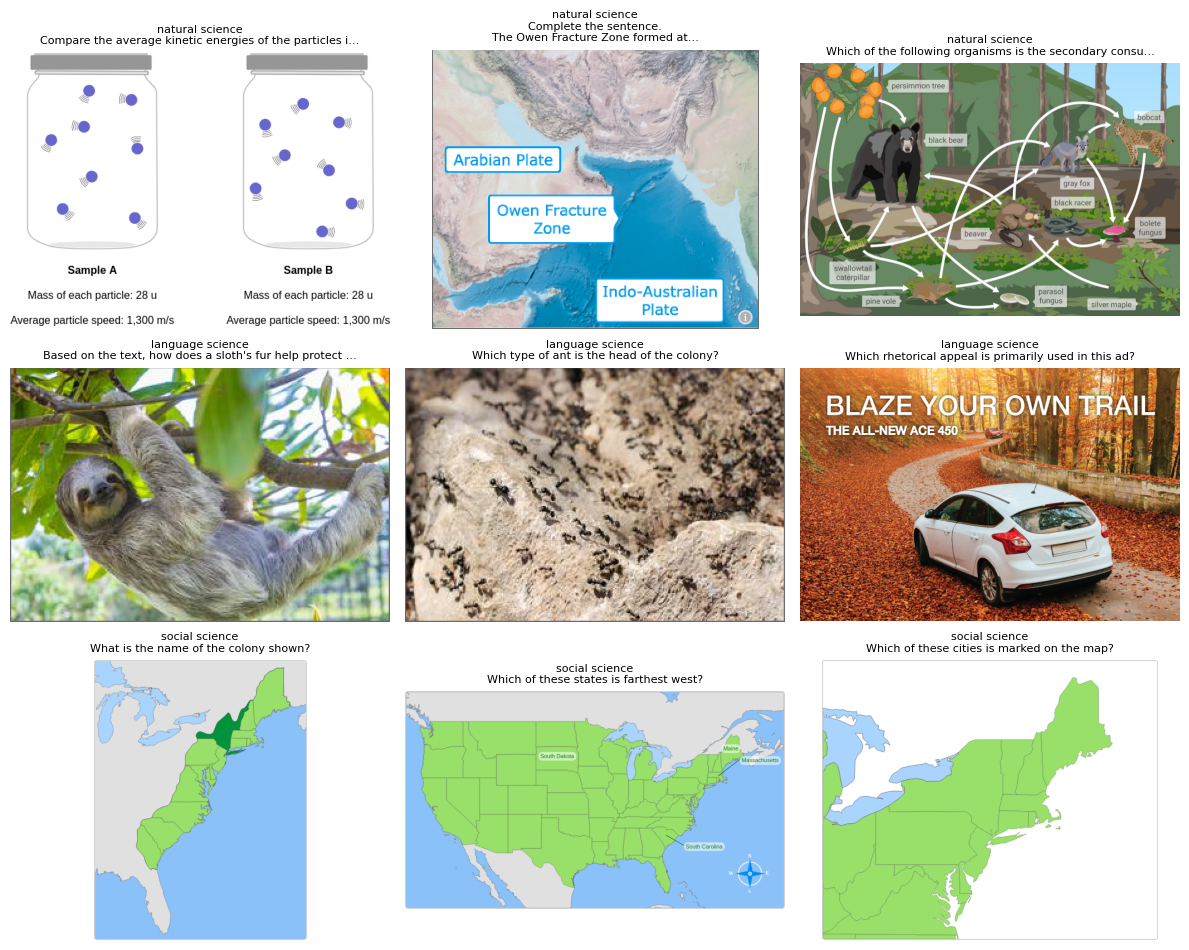

In [16]:
# Eyeball a few images per subject to understand visual content
def show_examples(df, n=2, subjects=None):
    if subjects is None:
        subjects = df["subject"].dropna().unique()
    fig, axes = plt.subplots(len(subjects), n,
                              figsize=(4 * n, 3.2 * len(subjects)))
    if len(subjects) == 1:
        axes = [axes]
    for row_axes, subj in zip(axes, subjects):
        sub = df[df["subject"] == subj].sample(
            min(n, len(df[df["subject"] == subj])), random_state=SEED
        )
        for ax, (_, row) in zip(row_axes, sub.iterrows()):
            try:
                ax.imshow(Image.open(DATA_DIR / row["image_path"]))
            except Exception:
                pass
            ax.axis("off")
            q = (row["question"][:55] + "…") if len(row["question"]) > 55 else row["question"]
            ax.set_title(f"{subj}\n{q}", fontsize=8)
    plt.tight_layout(); plt.show()

show_examples(train_df, n=3)

## 5. Zero-Shot Baselines

Four numbers that tell us where the project lives. Run before any training.

### 5a. Random Baseline

In [17]:
rng = np.random.default_rng(SEED)
rand_preds = [rng.integers(0, n) for n in val_df["num_choices"]]
rand_acc = float(np.mean(np.array(rand_preds) == val_df["answer"].values))
expected_rand = float((1.0 / val_df["num_choices"]).mean())

# 'Most common index' baseline — the real floor when there's position bias
most_common = train_df["answer"].mode()[0]
mc_preds = [min(most_common, n - 1) for n in val_df["num_choices"]]
mc_acc = float(np.mean(np.array(mc_preds) == val_df["answer"].values))

print(f"Random baseline (val):       {rand_acc:.4f}  (theoretical: {expected_rand:.4f})")
print(f"Most-common-index ({most_common}) (val):   {mc_acc:.4f}")

Random baseline (val):       0.3378  (theoretical: 0.3465)
Most-common-index (0) (val):   0.3311


### 5b. Lecture-Oracle Baseline

How often is the correct choice's text a substring of `lecture + hint`? Soft upper bound on what any text-only system could plausibly extract from context.

In [18]:
def lecture_oracle_predict(row):
    """For each choice, check if it appears in lecture+hint. Pick first match."""
    ctx = ""
    for col in ("lecture", "hint"):
        v = row.get(col)
        if isinstance(v, str):
            ctx += " " + v
    ctx = ctx.lower()
    if not ctx.strip():
        return -1  # no context, can't predict
    matches = [i for i, c in enumerate(row["choices"])
               if str(c).lower() in ctx]
    return matches[0] if matches else -1

val_df["oracle_pred"] = val_df.apply(lecture_oracle_predict, axis=1)
found = val_df["oracle_pred"] >= 0
oracle_acc_when_found = (val_df.loc[found, "oracle_pred"]
                          == val_df.loc[found, "answer"]).mean()
oracle_acc_overall = (val_df["oracle_pred"] == val_df["answer"]).mean()
print(f"Oracle finds at least one choice in context: {found.mean():.1%} of val")
print(f"Oracle accuracy when it finds a match:       {oracle_acc_when_found:.4f}")
print(f"Oracle accuracy overall (else wrong):        {oracle_acc_overall:.4f}")

Oracle finds at least one choice in context: 10.1% of val
Oracle accuracy when it finds a match:       0.5755
Oracle accuracy overall (else wrong):        0.0582


### 5c. Zero-Shot SmolVLM (Full Prompt)

Score each candidate letter token's logit at the answer position. Argmax over valid letters.

In [19]:
import torch
from transformers import AutoProcessor, AutoModelForVision2Seq

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"Device: {device}, dtype: {dtype}")

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
    low_cpu_mem_usage=True,
)
if not torch.cuda.is_available():
    model.to(device)
model.eval()

Skipping import of cpp extensions due to incompatible torch version 2.6.0+cu124 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda, dtype: torch.float16


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out

In [20]:
# Pre-compute token IDs for choice letters. Note: SmolVLM's tokenizer may
# encode " A" and "A" differently — we want the letter as it appears right
# after "Answer: ", which is preceded by a space.
letter_token_ids = {}
for letter in CHOICE_LETTERS:
    ids = processor.tokenizer.encode(f" {letter}", add_special_tokens=False)
    # Take the last token id — that's the letter token after any leading space
    letter_token_ids[letter] = ids[-1]
print("Letter token IDs:", letter_token_ids)
print("Decoded back:",
      {l: processor.tokenizer.decode([i]) for l, i in letter_token_ids.items()})

Letter token IDs: {'A': 330, 'B': 389, 'C': 340, 'D': 422, 'E': 414, 'F': 426, 'G': 452, 'H': 407, 'I': 339, 'J': 530}
Decoded back: {'A': ' A', 'B': ' B', 'C': ' C', 'D': ' D', 'E': ' E', 'F': ' F', 'G': ' G', 'H': ' H', 'I': ' I', 'J': ' J'}


In [21]:
IMG_SIZE = 224

@torch.inference_mode()
def score_question(row):
    """Return predicted choice index using next-token log-prob over letters."""
    img = Image.open(DATA_DIR / row["image_path"]).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)
    prompt = build_prompt_text(row)

    inputs = processor(text=[prompt], images=[img], return_tensors="pt")
    inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
              for k, v in inputs.items()}

    out = model(**inputs)
    next_logits = out.logits[0, -1]
    n = int(row["num_choices"])
    valid_ids = [letter_token_ids[CHOICE_LETTERS[i]] for i in range(n)]
    scores = next_logits[valid_ids].float().cpu().numpy()
    return int(np.argmax(scores))

ZS_N = 300
zs_sample = val_df.sample(min(ZS_N, len(val_df)), random_state=SEED).reset_index(drop=True)

preds = []
for _, row in tqdm(zs_sample.iterrows(), total=len(zs_sample), desc="Zero-shot"):
    preds.append(score_question(row))
preds = np.array(preds)
zs_acc = float((preds == zs_sample["answer"].values).mean())
print(f"Zero-shot SmolVLM (full prompt, n={len(zs_sample)}): {zs_acc:.4f}")

Zero-shot: 100%|██████████| 300/300 [01:23<00:00,  3.58it/s]

Zero-shot SmolVLM (full prompt, n=300): 0.5567


### 5d. Zero-Shot Text-Only

Same prompt, blank image. The gap between this and the full-prompt result is the visual contribution.

In [22]:
BLANK_IMG = Image.new("RGB", (IMG_SIZE, IMG_SIZE), color=(255, 255, 255))

@torch.inference_mode()
def score_question_text_only(row):
    prompt = build_prompt_text(row)
    inputs = processor(text=[prompt], images=[BLANK_IMG], return_tensors="pt")
    inputs = {k: v.to(model.device) if torch.is_tensor(v) else v
              for k, v in inputs.items()}
    out = model(**inputs)
    next_logits = out.logits[0, -1]
    n = int(row["num_choices"])
    valid_ids = [letter_token_ids[CHOICE_LETTERS[i]] for i in range(n)]
    scores = next_logits[valid_ids].float().cpu().numpy()
    return int(np.argmax(scores))

txt_preds = []
for _, row in tqdm(zs_sample.iterrows(), total=len(zs_sample), desc="Text-only"):
    txt_preds.append(score_question_text_only(row))
txt_preds = np.array(txt_preds)
txt_acc = float((txt_preds == zs_sample["answer"].values).mean())
print(f"Text-only zero-shot (n={len(zs_sample)}): {txt_acc:.4f}")
print(f"Image contribution: {zs_acc - txt_acc:+.4f}")

Text-only: 100%|██████████| 300/300 [01:21<00:00,  3.69it/s]

Text-only zero-shot (n=300): 0.5167
Image contribution: +0.0400


### 5e. Summary

In [23]:
summary = pd.DataFrame([
    {"baseline": "Random",                          "val_accuracy": rand_acc},
    {"baseline": f"Most-common-index ({most_common})", "val_accuracy": mc_acc},
    {"baseline": "Lecture oracle (substring)",      "val_accuracy": oracle_acc_overall},
    {"baseline": f"SmolVLM zero-shot text-only (n={len(zs_sample)})",
                                                      "val_accuracy": txt_acc},
    {"baseline": f"SmolVLM zero-shot full (n={len(zs_sample)})",
                                                      "val_accuracy": zs_acc},
])
summary["val_accuracy"] = summary["val_accuracy"].round(4)
summary

,baseline,val_accuracy
0,Random,0.3378
1,Most-common-index (0),0.3311
2,Lecture oracle (substring),0.0582
3,SmolVLM zero-shot text-only (n=300),0.5167
4,SmolVLM zero-shot full (n=300),0.5567


## 6. Per-Category Zero-Shot Breakdown

In [24]:
zs_sample = zs_sample.copy()
zs_sample["zs_pred"] = preds
zs_sample["correct"] = zs_sample["zs_pred"] == zs_sample["answer"]

for col in ["subject", "grade", "num_choices"]:
    print(f"\nZero-shot accuracy by {col}:")
    grp = zs_sample.groupby(col).agg(n=("correct", "size"),
                                      acc=("correct", "mean"))
    grp["acc"] = grp["acc"].round(3)
    print(grp.sort_values("acc", ascending=False))


Zero-shot accuracy by subject:
                    n    acc
subject                     
social science     55  0.600
natural science   239  0.552
language science    6  0.333

Zero-shot accuracy by grade:
          n    acc
grade             
grade5   23  0.652
grade4   51  0.647
grade3   38  0.605
grade7   52  0.558
grade8   78  0.526
grade6   50  0.500
grade2    7  0.143
grade12   1  0.000

Zero-shot accuracy by num_choices:
               n    acc
num_choices            
3            160  0.600
4             55  0.564
2             72  0.556
5             13  0.000


In [25]:
# Look at 5 failures by hand — what's hard?
wrong = zs_sample[~zs_sample["correct"]].sample(
    min(5, (~zs_sample["correct"]).sum()), random_state=SEED
)
for _, row in wrong.iterrows():
    print("=" * 70)
    print(f"id={row['id']}  subject={row.get('subject')}  grade={row.get('grade')}")
    print(f"Q: {row['question']}")
    print(f"Choices: {row['choices']}")
    print(f"Predicted: {row['zs_pred']}  |  Truth: {row['answer']}")
    if isinstance(row.get("hint"), str):
        print(f"Hint (truncated): {row['hint'][:200]}")

id=val_00146  subject=natural science  grade=grade8
Q: Which solution has a higher concentration of yellow particles?
Choices: ['Solution A', 'Solution B', 'neither; their concentrations are the same']
Predicted: 2  |  Truth: 1
Hint (truncated): The diagram below is a model of two solutions. Each yellow ball represents one particle of solute.
id=val_00085  subject=natural science  grade=grade8
Q: What is the expected ratio of offspring with fuzzy leaves to offspring with smooth leaves? Choose the most likely ratio.
Choices: ['0:4', '1:3', '4:0', '3:1', '2:2']
Predicted: 0  |  Truth: 4
Hint (truncated): In a group of summer squash plants, some individuals have fuzzy leaves and others have smooth leaves. In this group, the gene for the leaf texture trait has two alleles. The allele for fuzzy leaves (L
id=val_04183  subject=social science  grade=grade7
Q: What can Dean and Estelle trade to each get what they want?
Choices: ["Dean can trade his tomatoes for Estelle's carrots.", "Estelle ca